In [2]:
import torchvision
from torch.utils.data import DataLoader
from torch import nn
import torch

In [51]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.RandomHorizontalFlip(),  # 随机水平翻转（增强）
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))  # 标准化
])
train_data = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_data = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

In [52]:
train_loader = DataLoader(train_data,batch_size=64)
test_loader = DataLoader(test_data,batch_size=64,shuffle=True)

In [53]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3,32,5,1,2),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32,32,5,1,2),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32,64,5,1,2),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64*4*4,64),
            nn.Linear(64,10)
        )
    
    def forward(self, x):
        x = self.model(x)
        return x

In [54]:
net = Net()
loss_fn = nn.CrossEntropyLoss()
learn_rate = 0.01
optimizer = torch.optim.SGD(net.parameters(), lr=learn_rate)

In [55]:
total_train_step =0
total_test_step =0
epoch = 11

In [56]:
for i in range(epoch):
    print("第{}轮训练".format(i+1))
    for data in train_loader:
        imgs,targets = data
        outputs = net(imgs)
        loss = loss_fn(outputs,targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_step +=1
        print("第{}步训练，损失为{}".format(total_train_step,loss))
    total_test_loss = 0
    total_accuracy = 0
    with torch.no_grad():
        for data in test_loader:
            imgs,targets = data
            outputs = net(imgs)
            loss = loss_fn(outputs,targets)
            total_test_loss += loss
            accuracy = (outputs.argmax(1)==targets).sum()
            total_accuracy += accuracy
    print("整体测试集的损失为{}".format(total_test_loss))
    print("整体测试集的正确率为{}".format(total_accuracy/len(test_data)))
    if i%5==0:
        torch.save(net,"net_{}.pth".format(i))

第1轮训练
第1步训练，损失为2.298222064971924
第2步训练，损失为2.3067641258239746
第3步训练，损失为2.310849666595459
第4步训练，损失为2.297351121902466
第5步训练，损失为2.3067212104797363
第6步训练，损失为2.3085830211639404
第7步训练，损失为2.313955783843994
第8步训练，损失为2.2971737384796143
第9步训练，损失为2.3007090091705322
第10步训练，损失为2.3107147216796875
第11步训练，损失为2.3111672401428223
第12步训练，损失为2.310392379760742
第13步训练，损失为2.295774459838867
第14步训练，损失为2.2979767322540283
第15步训练，损失为2.3038179874420166
第16步训练，损失为2.2906806468963623
第17步训练，损失为2.308854103088379
第18步训练，损失为2.315377712249756
第19步训练，损失为2.3091602325439453
第20步训练，损失为2.3123085498809814
第21步训练，损失为2.2930736541748047
第22步训练，损失为2.3024511337280273
第23步训练，损失为2.3035011291503906
第24步训练，损失为2.3028554916381836
第25步训练，损失为2.3084068298339844
第26步训练，损失为2.295712947845459
第27步训练，损失为2.29862904548645
第28步训练，损失为2.3009400367736816
第29步训练，损失为2.2996838092803955
第30步训练，损失为2.324190139770508
第31步训练，损失为2.2996110916137695
第32步训练，损失为2.3055431842803955
第33步训练，损失为2.3014020919799805
第34步训练，损失为2.3002946376800537
第35步训练，损失为2.294387102127075
第

In [85]:
net = torch.load("net_10.pth", weights_only=False)
net.train()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(net.parameters(), lr=0.01)
total_train_step =0
total_test_step =0
epoch = 11

In [84]:

for i in range(epoch):
    print("第{}轮训练".format(i+1))
    for data in train_loader:
        imgs,targets = data
        outputs = net(imgs)
        loss = loss_fn(outputs,targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_train_step +=1
        print("第{}步训练，损失为{}".format(total_train_step,loss))
    total_test_loss = 0
    total_accuracy = 0
    with torch.no_grad():
        for data in test_loader:
            imgs,targets = data
            outputs = net(imgs)
            loss = loss_fn(outputs,targets)
            total_test_loss += loss
            accuracy = (outputs.argmax(1)==targets).sum()
            total_accuracy += accuracy
    print("整体测试集的损失为{}".format(total_test_loss))
    print("整体测试集的正确率为{}".format(total_accuracy/len(test_data)))
    if i%5==0 and i!=0:
        torch.save(net,"net_{}.pth".format(i))

第1轮训练
第1步训练，损失为0.5881276726722717
第2步训练，损失为0.46806302666664124
第3步训练，损失为0.6473408937454224
第4步训练，损失为0.4174773395061493
第5步训练，损失为0.579012393951416
第6步训练，损失为0.6532676219940186
第7步训练，损失为0.4505574107170105
第8步训练，损失为0.46636763215065
第9步训练，损失为0.4125569462776184
第10步训练，损失为0.5074693560600281
第11步训练，损失为0.6146165728569031
第12步训练，损失为0.621184766292572
第13步训练，损失为0.6975088715553284
第14步训练，损失为0.5721646547317505
第15步训练，损失为0.6138678193092346
第16步训练，损失为0.4113306701183319
第17步训练，损失为0.5316658616065979
第18步训练，损失为0.5840062499046326
第19步训练，损失为0.5098024606704712
第20步训练，损失为0.37673163414001465
第21步训练，损失为0.5066076517105103
第22步训练，损失为0.5806105732917786
第23步训练，损失为0.4494483172893524
第24步训练，损失为0.5941121578216553
第25步训练，损失为0.5904979705810547
第26步训练，损失为0.5491384267807007
第27步训练，损失为0.5583108067512512
第28步训练，损失为0.47831541299819946
第29步训练，损失为0.4237510859966278
第30步训练，损失为0.3223809003829956
第31步训练，损失为0.5627365708351135
第32步训练，损失为0.5884642601013184
第33步训练，损失为0.3032424747943878
第34步训练，损失为0.503862738609314
第35步训练，损失为0.6715498

In [86]:
classes = [
    'plane', 'car', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]
testtotal_accuracy = 0
testtotal_num = len(test_data)
nettry = torch.load('net_10.pth',weights_only=False)
nettry.eval()
with torch.no_grad():
    for data in test_loader:
        imgs,targets = data
        outputs = nettry(imgs)
        testaccuracy = (outputs.argmax(1)==targets).sum()
        testtotal_accuracy += testaccuracy
acc = testtotal_accuracy / testtotal_num
print(f"模型测试准确率：{acc:.2%}")
print(f"总测试图片：{testtotal_num}，正确预测：{testtotal_accuracy}")

模型测试准确率：74.04%
总测试图片：10000，正确预测：7404


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


真实标签： horse
模型预测： horse


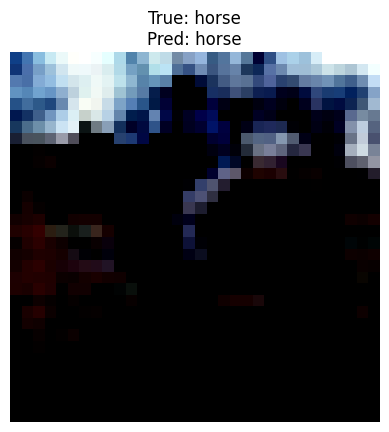

In [95]:
import matplotlib.pyplot as plt
import numpy as np

# 取一批测试数据
dataiter = iter(test_loader)
images, labels = next(dataiter)

# 预测
with torch.no_grad():
    outputs = nettry(images)
_, preds = torch.max(outputs, 1)

# 打印第一张图片结果
print("真实标签：", classes[labels[0]])
print("模型预测：", classes[preds[0]])

# 显示图片
img = images[0].numpy().transpose((1, 2, 0))
plt.imshow(img)
plt.title(f"True: {classes[labels[0]]}\nPred: {classes[preds[0]]}")
plt.axis('off')
plt.show()